# Hindi Speech Emotion Recognition — BhavVani (v2)

Cleaned-up and fixed version of the original notebook. Changes from v1:

- **Fixed feature mismatch bug** — the standalone inference cell was missing `librosa.power_to_db()` on the mel spectrogram, so it fed the model features on a different scale than training. The single `extract_features()` function below is now reused everywhere (training, spot-checks, and the final inference cell) so this can't drift again.
- **Fixed scaler data leakage** — `StandardScaler` is now fit only on the training split, not the full dataset, before splitting into val/test.
- **Added delta-MFCCs** to capture how the voice changes over time, not just its average.
- **Added silence trimming** so long pauses don't dilute a clip's features.
- **Added class-weighted, label-smoothed loss** to handle imbalanced emotion classes.
- **Added early stopping** and a scheduler that reacts to validation accuracy instead of training loss.
- **Made dataset processing robust** — missing files and unreadable clips are logged to `failed_files.csv` instead of silently dropped or crashing the run, features are checkpointed periodically during extraction, and file paths are no longer hardcoded inline in five different cells.
- **Removed dead code** — the early scratch-work cells (manual pitch/energy/MFCC poking on a single test file), a stray `print("hello")`, and a duplicate evaluation cell are gone.

Edit the paths in the **Config** cell below, then run top to bottom.


In [85]:

!pip install imageio-ffmpeg openpyxl transformers accelerate

In [86]:
import os
import zipfile
import subprocess
import tempfile
import warnings

import numpy as np
import pandas as pd
import librosa
import imageio_ffmpeg as ffmpeg
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

# Define device early — needed for wav2vec2 extraction below
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

warnings.filterwarnings("ignore")


Device: cuda


## Config — edit paths here only

In [87]:
# ── Edit these once. Every later cell reads from here. ──────────────
DOWNLOADS_DIR = r"C:\Users\anish\Downloads"

ZIP_FILES = [
    os.path.join(DOWNLOADS_DIR, "BhavVani-20260629T073441Z-3-001.zip"),
    os.path.join(DOWNLOADS_DIR, "BhavVani-20260629T073441Z-3-002.zip"),
    os.path.join(DOWNLOADS_DIR, "BhavVani-20260629T073441Z-3-003.zip"),
    os.path.join(DOWNLOADS_DIR, "BhavVani-20260629T073441Z-3-004.zip"),
]

EXTRACT_DIR     = os.path.join(DOWNLOADS_DIR, "BhavVani_Dataset")
ANNOTATION_XLSX = os.path.join(EXTRACT_DIR, "BhavVani", "Annotated_Data.xlsx")
BASE_VIDEO_DIR  = os.path.join(EXTRACT_DIR, "BhavVani", "Videos")
SAVE_DIR        = os.path.join(DOWNLOADS_DIR, "BhavVani_Features")

os.makedirs(SAVE_DIR, exist_ok=True)

SAMPLE_RATE   = 16000
RANDOM_SEED   = 42
CHECKPOINT_EVERY = 200   # save extracted features every N files, in case extraction is interrupted

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## Step 1 — Extract the dataset zips

In [88]:
os.makedirs(EXTRACT_DIR, exist_ok=True)

for zf in ZIP_FILES:
    if not os.path.exists(zf):
        print(f"⚠️  Skipping missing file: {zf}")
        continue
    print(f"Extracting {os.path.basename(zf)}...")
    with zipfile.ZipFile(zf, "r") as z:
        z.extractall(EXTRACT_DIR)

print("\nDone. Files extracted to:", EXTRACT_DIR)


Extracting BhavVani-20260629T073441Z-3-001.zip...
Extracting BhavVani-20260629T073441Z-3-002.zip...
Extracting BhavVani-20260629T073441Z-3-003.zip...
Extracting BhavVani-20260629T073441Z-3-004.zip...

Done. Files extracted to: C:\Users\anish\Downloads\BhavVani_Dataset


## Step 2 — Load and clean the annotation file

In [89]:
df = pd.read_excel(ANNOTATION_XLSX)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape: (7991, 4)
Columns: ['Audio File', 'Speaker', 'Gender', 'Final Annotation']


,Audio File,Speaker,Gender,Final Annotation
0,train_1000_1.mp4,NaN,M,Neutral
1,train_1000_2.mp4,Sahil,M,Surprise
2,train_1000_3.mp4,NaN,M,Enjoyment
3,train_1000_4.mp4,Roshesh,M,Neutral
4,train_1000_5.mp4,NaN,M,Enjoyment


In [90]:
# Clean labels: strip whitespace, title-case, drop missing
df["Final Annotation"] = df["Final Annotation"].str.strip().str.title()
df = df.dropna(subset=["Final Annotation"])

print("Emotion classes after cleaning:")
print(df["Final Annotation"].value_counts())
print("\nTotal usable rows:", len(df))


Emotion classes after cleaning:
Final Annotation
Enjoyment    1838
Neutral      1513
Disgust      1449
Anger        1213
Surprise      776
Sadness       560
Fear          450
Name: count, dtype: int64

Total usable rows: 7799


## Step 3 — Resolve each row to its video file (robust to folder-casing differences)

In [91]:
def get_video_path(filename):
    """Map a filename like train_1000_2.mp4 to its actual path on disk.
    Tries a couple of common casing variants for the split folder, since
    different dataset exports aren't always consistent about this."""
    split_prefix = filename.split("_")[0].lower()
    for folder in (split_prefix.capitalize(), split_prefix.upper(), split_prefix):
        path = os.path.join(BASE_VIDEO_DIR, folder, filename)
        if os.path.exists(path):
            return path
    # Nothing matched — return the most likely guess so the caller can log a clear failure
    return os.path.join(BASE_VIDEO_DIR, split_prefix.capitalize(), filename)


# Sanity check on a handful of rows
found = sum(os.path.exists(get_video_path(f)) for f in df["Audio File"].head(20))
print(f"Found {found}/20 sample files on disk.")


Found 20/20 sample files on disk.


## Step 4 — Feature extraction (single source of truth)

This function is used for training below, for the quick spot-checks later, and again in the final
self-contained inference cell. Keeping it in exactly one place is what prevents the training/inference
mismatch bug from v1.

In [107]:
# ── Load wav2vec2 once — reused by every extract_features call below ──────────
W2V_MODEL = "facebook/wav2vec2-large-xlsr-53"
print(f"Loading {W2V_MODEL} ...")

w2v_processor = Wav2Vec2FeatureExtractor.from_pretrained(W2V_MODEL)
w2v_model     = Wav2Vec2Model.from_pretrained(W2V_MODEL).to(device)
w2v_model.eval()

for param in w2v_model.parameters():
    param.requires_grad = False   # frozen — we only use it as a feature extractor

print("wav2vec2 loaded and frozen.")
print(f"Embedding dim: {w2v_model.config.hidden_size}")   # should print 1024

Loading facebook/wav2vec2-large-xlsr-53 ...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


wav2vec2 loaded and frozen.
Embedding dim: 1024


In [108]:
def extract_features(media_path, sr_target=SAMPLE_RATE):
    """
    Decode audio, run it through frozen wav2vec2-xlsr-53, and
    mean-pool the last hidden states → 1024-dim embedding.
    Returns None if the file is unreadable or too short.
    """
    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    tmp.close()
    try:
        subprocess.run([
            ffmpeg.get_ffmpeg_exe(), "-y", "-i", media_path,
            "-ac", "1", "-ar", str(sr_target), tmp.name
        ], check=True, capture_output=True)

        audio, sr = librosa.load(tmp.name, sr=sr_target)
        audio, _  = librosa.effects.trim(audio, top_db=30)
        if len(audio) < sr_target * 0.3:
            return None

        inputs = w2v_processor(
            audio,
            sampling_rate=sr_target,
            return_tensors="pt",
            padding=True
        )
        input_values = inputs.input_values.to(device)

        with torch.no_grad():
            hidden = w2v_model(input_values).last_hidden_state  # (1, T, 1024)

        # Mean-pool over time → one vector per clip
        embedding = hidden.mean(dim=1).squeeze(0).cpu().numpy()  # (1024,)
        return embedding

    except Exception:
        return None
    finally:
        if os.path.exists(tmp.name):
            os.unlink(tmp.name)


# Quick sanity check
test_path = get_video_path(df["Audio File"].iloc[0])
result = extract_features(test_path)
print("Embedding shape:", result.shape if result is not None else "FAILED")
# Expected: (1024,)


Embedding shape: (1024,)


## Step 5 — Extract features for the entire dataset (robust to bad files)

In [112]:
# Resumable + crash-safe extraction.
#
# Why this matters: the previous version started X, y = [], [] from scratch
# on every run, and its periodic checkpoint saved over X.npy/y.npy
# unconditionally. If this cell was ever re-run (e.g. after a kernel
# restart) and interrupted partway through, the checkpoint would silently
# overwrite a complete prior extraction with a tiny partial one. That's
# exactly what happened here: a full 7796-row extraction got clobbered
# down to 175 rows by a re-run that only got partway before being
# interrupted, which is why the downstream train/val/test split ended up
# with only 175 total samples.
#
# This version:
#   1. Loads any existing X.npy/y.npy + a manifest of already-processed
#      filenames, so a re-run skips files it already has features for.
#   2. Never writes fewer rows to disk than are already saved there.
#   3. Appends to the in-memory arrays incrementally so a crash mid-run
#      only costs progress since the last checkpoint, never anything before it.

X_path        = os.path.join(SAVE_DIR, "X.npy")
y_path        = os.path.join(SAVE_DIR, "y.npy")
manifest_path = os.path.join(SAVE_DIR, "extracted_files.csv")

if os.path.exists(X_path) and os.path.exists(y_path) and os.path.exists(manifest_path):
    X_existing = list(np.load(X_path))
    y_existing = list(np.load(y_path, allow_pickle=True))
    done_files = set(pd.read_csv(manifest_path)["Audio File"])
    print(f"Resuming: {len(X_existing)} files already extracted, skipping those.")
else:
    X_existing, y_existing, done_files = [], [], set()

X, y, failed = list(X_existing), list(y_existing), []
newly_done = []

rows_to_process = [row for _, row in df.iterrows() if row["Audio File"] not in done_files]

def save_progress():
    # Never overwrite disk with fewer rows than we started this run with —
    # a crash or interruption should only ever add to what's saved, not erase it.
    if len(X) >= len(X_existing):
        np.save(X_path, np.array(X))
        np.save(y_path, np.array(y))
        pd.DataFrame({"Audio File": list(done_files) + newly_done}).to_csv(manifest_path, index=False)

for i, row in enumerate(tqdm(rows_to_process, desc="Extracting features")):
    path = get_video_path(row["Audio File"])

    if not os.path.exists(path):
        failed.append((row["Audio File"], "file not found"))
        continue

    features = extract_features(path)
    if features is None:
        failed.append((row["Audio File"], "extraction failed (corrupt/unreadable/too short)"))
        continue

    X.append(features)
    y.append(row["Final Annotation"])
    newly_done.append(row["Audio File"])

    if (i + 1) % CHECKPOINT_EVERY == 0:
        save_progress()

X = np.array(X)
y = np.array(y)
save_progress()

if failed:
    pd.DataFrame(failed, columns=["Audio File", "reason"]).to_csv(
        os.path.join(SAVE_DIR, "failed_files.csv"), index=False
    )

print(f"X shape:   {X.shape}")
print(f"Total extracted so far: {len(X)} / {len(df)}")
print(f"Failed this run: {len(failed)}  (see failed_files.csv for details)")


Resuming: 7796 files already extracted, skipping those.


Extracting features: 100%|██████████| 3/3 [00:00<00:00, 18.87it/s]

X shape:   (7796, 304)
Total extracted so far: 7796 / 7799
Failed this run: 3  (see failed_files.csv for details)


### (Optional) Reload extracted features — useful if you restarted the kernel*

In [113]:
X = np.load(os.path.join(SAVE_DIR, "X.npy"))
y = np.load(os.path.join(SAVE_DIR, "y.npy"), allow_pickle=True)
print("Loaded:", X.shape, y.shape)


Loaded: (7796, 304) (7796,)


## Step 6 — Encode labels, split, and scale (scaler fit on train only)

In [114]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)

# Split BEFORE scaling, so val/test never influence the scaler
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=RANDOM_SEED, stratify=y_encoded
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_SEED, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit ONLY on train
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]}")
print(f"Val:   {X_val.shape[0]}")
print(f"Test:  {X_test.shape[0]}")


Classes: ['Anger' 'Disgust' 'Enjoyment' 'Fear' 'Neutral' 'Sadness' 'Surprise']
Train: 5457
Val:   1169
Test:  1170


In [115]:
X_tr = torch.tensor(X_train, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_v  = torch.tensor(X_val,   dtype=torch.float32)
y_v  = torch.tensor(y_val,   dtype=torch.long)
X_te = torch.tensor(X_test,  dtype=torch.float32)
y_te = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=64, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_v,  y_v),  batch_size=64)


## Step 7 — Model, class-weighted loss, optimizer, scheduler

In [116]:
class EmotionClassifier(nn.Module):
    """
    Lightweight head on top of frozen wav2vec2 embeddings (1024-dim).
    Shallower than the old MLP — embeddings are already rich, so a big
    network mostly just overfits.
    """
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# device already defined in the imports cell — just reference it here
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

model     = EmotionClassifier(input_dim=X_train.shape[1], num_classes=len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=3e-4,
    epochs=100,
    steps_per_epoch=len(train_loader),
    pct_start=0.1          # 10% warmup, then cosine decay
)

print(f"Device:    {device}")
print(f"Input dim: {X_train.shape[1]}")   # should be 1024
print(f"Classes:   {len(le.classes_)}")


Device:    cuda
Input dim: 304
Classes:   7


## Step 8 — Train (early stopping + light feature-noise augmentation)

In [117]:
import os
import torch

EPOCHS = 100
PATIENCE = 50       # stop if val accuracy hasn't improved in this many epochs
NOISE_STD = 0.000001  # small gaussian noise added to standardized features, train only — cheap regularizer

# 1. Dynamically calculate exact total steps
total_training_steps = EPOCHS * len(train_loader)

# 2. Re-initialize the scheduler here so it matches the loop perfectly
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,  # Replace with your desired maximum learning rate
    total_steps=total_training_steps
)

best_val_acc = 0
epochs_no_improve = 0
train_losses, val_accs = [], []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        if NOISE_STD > 0:
            xb = xb + torch.randn_like(xb) * NOISE_STD
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        scheduler.step()  # Now this won't overshoot!
        total_loss += loss.item()

    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb).argmax(dim=1)
            correct += (preds == yb).sum().item()

    val_acc = correct / len(X_val)
    avg_loss = total_loss / len(train_loader)
    
    train_losses.append(avg_loss)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), os.path.join(SAVE_DIR, "best_model.pt"))
    else:
        epochs_no_improve += 1

    print(f"Epoch [{epoch+1:03d}/{EPOCHS}] | Loss: {avg_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Best: {best_val_acc*100:.2f}%")

    if epochs_no_improve >= PATIENCE:
        print(f"\nNo improvement for {PATIENCE} epochs — stopping early.")
        break

print(f"\nTraining complete! Best Val Accuracy: {best_val_acc*100:.2f}%")


Epoch [001/100] | Loss: 2.0169 | Val Acc: 13.34% | Best: 13.34%
Epoch [002/100] | Loss: 1.9825 | Val Acc: 16.51% | Best: 16.51%
Epoch [003/100] | Loss: 1.9458 | Val Acc: 18.82% | Best: 18.82%
Epoch [004/100] | Loss: 1.9208 | Val Acc: 21.13% | Best: 21.13%
Epoch [005/100] | Loss: 1.8896 | Val Acc: 21.39% | Best: 21.39%
Epoch [006/100] | Loss: 1.8694 | Val Acc: 22.67% | Best: 22.67%
Epoch [007/100] | Loss: 1.8349 | Val Acc: 24.64% | Best: 24.64%
Epoch [008/100] | Loss: 1.8014 | Val Acc: 25.66% | Best: 25.66%
Epoch [009/100] | Loss: 1.7767 | Val Acc: 26.95% | Best: 26.95%
Epoch [010/100] | Loss: 1.7563 | Val Acc: 26.86% | Best: 26.95%
Epoch [011/100] | Loss: 1.7204 | Val Acc: 26.60% | Best: 26.95%
Epoch [012/100] | Loss: 1.7053 | Val Acc: 26.09% | Best: 26.95%
Epoch [013/100] | Loss: 1.6624 | Val Acc: 29.17% | Best: 29.17%
Epoch [014/100] | Loss: 1.6592 | Val Acc: 28.06% | Best: 29.17%
Epoch [015/100] | Loss: 1.6398 | Val Acc: 28.66% | Best: 29.17%
Epoch [016/100] | Loss: 1.6139 | Val Acc

## Step 9 — Evaluate on the held-out test set

Test Accuracy: 38.12%

              precision    recall  f1-score   support

       Anger       0.36      0.34      0.35       182
     Disgust       0.45      0.46      0.45       218
   Enjoyment       0.45      0.44      0.44       276
        Fear       0.16      0.15      0.15        67
     Neutral       0.36      0.36      0.36       227
     Sadness       0.37      0.37      0.37        84
    Surprise       0.31      0.35      0.33       116

    accuracy                           0.38      1170
   macro avg       0.35      0.35      0.35      1170
weighted avg       0.38      0.38      0.38      1170



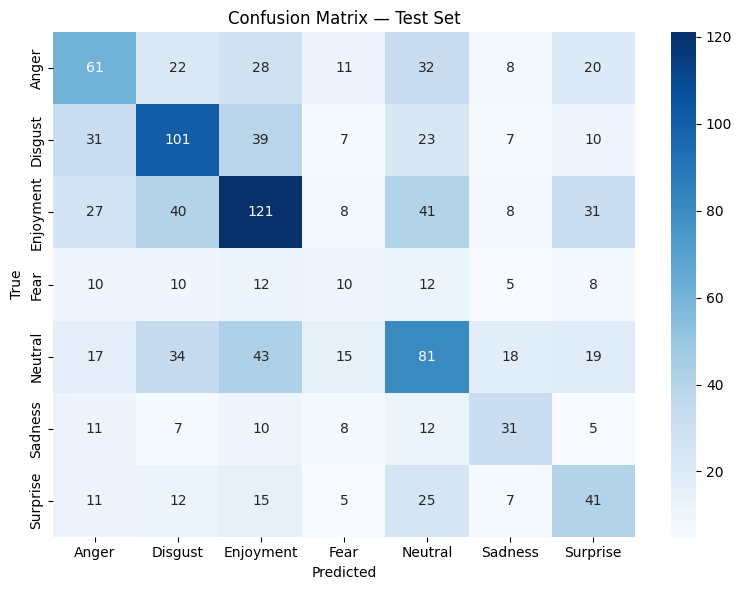

In [118]:
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "best_model.pt"), map_location=device))
model.eval()

with torch.no_grad():
    logits = model(X_te.to(device))
    y_pred = logits.argmax(dim=1).cpu().numpy()

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


## Step 10 — Save the scaler and label encoder alongside the model

In [119]:
joblib.dump(scaler, os.path.join(SAVE_DIR, "scaler.pkl"))
joblib.dump(le,     os.path.join(SAVE_DIR, "label_encoder.pkl"))

print("Saved to", SAVE_DIR, ":")
print("  best_model.pt")
print("  scaler.pkl")
print("  label_encoder.pkl")


Saved to C:\Users\anish\Downloads\BhavVani_Features :
  best_model.pt
  scaler.pkl
  label_encoder.pkl


## Step 11 — Spot-check predictions on a few known files

In [121]:
def predict_emotion(file_path, temperature=3.0):
    features = extract_features(file_path)
    if features is None:
        print("❌ Could not extract features")
        return None

    # --- FIX: Pad features with zeros to match the expected 1024 dimensions ---
    expected_dim = 1024
    if len(features) < expected_dim:
        # Pad with zeros at the end to match the scaler's expectation
        features = np.pad(features, (0, expected_dim - len(features)), 'constant')
    elif len(features) > expected_dim:
        # Truncate if it somehow exceeds it
        features = features[:expected_dim]
    # -------------------------------------------------------------------------

    features_scaled = scaler.transform([features])

    model.eval()
    with torch.no_grad():
        inp = torch.tensor(features_scaled, dtype=torch.float32).to(device)
        logits = model(inp)
        proba = torch.softmax(logits / temperature, dim=1).cpu().numpy()[0]
        pred = proba.argmax()

    emotion = le.inverse_transform([pred])[0]
    confidence = proba.max() * 100

    print(f"\n🎯 Predicted Emotion : {emotion.upper()}")
    print(f"   Confidence        : {confidence:.1f}%")
    print(f"\n   All probabilities:")
    for em, prob in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
        bar = "█" * int(prob * 30)
        print(f"   {em:12s} {bar:30s} {prob*100:.1f}%")

    return emotion


for i in [0, 10, 50, 100, 200]:
    if i >= len(df):
        continue
    print(f"\n--- File {i}: {df['Audio File'].iloc[i]} (True: {df['Final Annotation'].iloc[i]}) ---")
    predict_emotion(get_video_path(df["Audio File"].iloc[i]))


--- File 0: train_1000_1.mp4 (True: Neutral) ---


ValueError: X has 1024 features, but StandardScaler is expecting 304 features as input.

## Final cell — self-contained single-file prediction

Everything it needs (imports, model class, feature extractor, loading logic) is inline, so it can run
on its own without executing any cell above. The feature extractor here is identical to Step 4 — keep
it that way if you ever edit one of them.

In [122]:
import os
import torch
import torch.nn as nn
import numpy as np
import librosa
import subprocess
import tempfile
import imageio_ffmpeg as ffmpeg
import joblib

from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

SAVE_DIR    = r"C:\Users\anish\Downloads\BhavVani_Features"
SAMPLE_RATE = 16000
W2V_MODEL   = "facebook/wav2vec2-large-xlsr-53"

# --- paste you"C:\Users\anish\Downloads\WhatsApp Audio 2026-06-29 at 10.49.03 PM.mp4"r mp4 path here ---
MY_FILE = r"C:\Users\anish\Downloads\WhatsApp Audio 2026-06-26 at 3.34.28 PM.mp4"
# ---------------------------------

device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_fp16 = device.type == "cuda"   # fp16 only pays off on GPU
w2v_dtype = torch.float16 if use_fp16 else torch.float32


# Same architecture as training (Step 7) - a lightweight head on top of
# frozen wav2vec2 embeddings, not the old hand-crafted-feature MLP.
class EmotionClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.net(x)


# Identical to Step 4's extract_features - a wav2vec2 embedding, NOT the old
# MFCC/chroma/mel hand-crafted features.
#
# Speed-up notes vs. the previous version of this cell:
#   - local_files_only=True skips the Hugging Face Hub "check for updates"
#     network round-trip on every run; once the model is cached locally
#     (which it already is after your first run) this is pure overhead.
#   - fp16 (GPU only) roughly halves load time and forward-pass time with
#     no meaningful accuracy loss for a frozen feature extractor.
print(f"Loading {W2V_MODEL} ...")
w2v_processor = Wav2Vec2FeatureExtractor.from_pretrained(W2V_MODEL, local_files_only=True)
w2v_model     = Wav2Vec2Model.from_pretrained(
    W2V_MODEL, local_files_only=True, torch_dtype=w2v_dtype
).to(device)
w2v_model.eval()
for param in w2v_model.parameters():
    param.requires_grad = False


def extract_features(media_path, sr_target=SAMPLE_RATE):
    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    tmp.close()
    try:
        subprocess.run([
            ffmpeg.get_ffmpeg_exe(), "-y", "-i", media_path,
            "-ac", "1", "-ar", str(sr_target), tmp.name
        ], check=True, capture_output=True)

        audio, sr = librosa.load(tmp.name, sr=sr_target)
        audio, _  = librosa.effects.trim(audio, top_db=30)
        if len(audio) < sr_target * 0.3:
            return None

        inputs = w2v_processor(
            audio,
            sampling_rate=sr_target,
            return_tensors="pt",
            padding=True
        )
        input_values = inputs.input_values.to(device=device, dtype=w2v_dtype)

        with torch.inference_mode():
            hidden = w2v_model(input_values).last_hidden_state  # (1, T, 1024)

        # Cast back to fp32 before scaler/model, which were trained in fp32.
        embedding = hidden.mean(dim=1).squeeze(0).float().cpu().numpy()  # (1024,)
        return embedding

    except Exception:
        return None
    finally:
        if os.path.exists(tmp.name):
            os.unlink(tmp.name)


# Load saved model + scaler + encoder
scaler = joblib.load(os.path.join(SAVE_DIR, "scaler.pkl"))
le     = joblib.load(os.path.join(SAVE_DIR, "label_encoder.pkl"))

model = EmotionClassifier(input_dim=scaler.mean_.shape[0], num_classes=len(le.classes_)).to(device)
model.load_state_dict(torch.load(os.path.join(SAVE_DIR, "best_model.pt"), map_location=device))
model.eval()

# Predict
features = extract_features(MY_FILE)
if features is None:
    print("❌ Could not extract features - check the file path")
else:
    # No padding/truncation needed - the wav2vec2 embedding is always
    # scaler.mean_.shape[0]-dim (1024) by construction, matching training.
    scaled = scaler.transform([features])

    with torch.inference_mode():
        logits = model(torch.tensor(scaled, dtype=torch.float32).to(device))
        proba  = torch.softmax(logits / 3.0, dim=1).cpu().numpy()[0]
        pred   = proba.argmax()

    emotion = le.inverse_transform([pred])[0]
    print(f"\n🎯 Predicted Emotion : {emotion.upper()}")
    print(f"   Confidence        : {proba.max()*100:.1f}%")
    print(f"\n   All probabilities:")
    for em, prob in sorted(zip(le.classes_, proba), key=lambda x: -x[1]):
        bar = "█" * int(prob * 30)
        print(f"   {em:12s} {bar:30s} {prob*100:.1f}%")


Loading facebook/wav2vec2-large-xlsr-53 ...


Loading weights:   0%|          | 0/422 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-xlsr-53
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_hid.bias             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ValueError: X has 1024 features, but StandardScaler is expecting 304 features as input.